# Main Data Analysis

The new FRETBursts is designed around the idea that \[single molecule diffusion base burst\] data analysis should be
1. Fully reproducible
2. As simple as possible but no simpler
    1. Analysis should explain to the user what is being done
    2. Boilerplate code should be reduced as much as possible
4. Everything important the user can see
5. Everything unimporant handled behind the scenes
6. Pseudo-stateless\* ie the user should be able to retrieve the same data with the same function call regardless of preveious actions

\* Compared to the previous version, this is the main advantage of the new FRETBursts, as the previous FRETBursts constantly modified the state.

## Outline of normal burst analysis steps

The basic pipline of data analysis is derived from [Ingargiola 2016](http://dx.doi.org/10.1371/journal.pone.0160716).

Here are the basic steps:

1. Background analysis
    - Define periods
    - Compute background per period
2. Burst Search
    - sliding window analysis
    - set correction factors
4. Burst Selection (Gating/Thresholding)
5. Visualization and analysis of burst parameters

It should be noted that often setting correction factors and burst selection are often performed together.

## New FRETBursts Datamodel

The new FRETBursts works with an underlying data model, which we will explain as we go.
But a bried summary will be helpful.

Raw data is stored in `frb.PhotonData` objects.
Instructions for data analyis are specified as `frb.Param`s.
Further specification and gating of data is done through `frb.Column` and `frb.GateGroup` objects.
`frb.Param`, `frb.Column` and `frb.GateGroup` objects are all immutable, and can be represented simply

When the you to perform a given analysis, you specify the instructions with `frb.Param`, `frb.Column` and `frb.GateGroup` objects,
which you then use `frb.PhotonData.get_...(instruction)` methods to perform said analysis on the data in the `frb.PhotonData` object.

A key aspect of the pseudo-stateless behavior of FRETBursts is that regardless of what other `frb.PhotonData.get_...()` methods have
been called, if you give the same instructions (either exact same object, or just one with the same internal values),
you will get back the same data.

The "pseudo" is simple that FRETBursts does cache some computed values. So internally, what has been done before
is remembered, but only makes every retrieval after the first faster than the first.

## Data Analysis

First, we need to import FRETBursts into the Python environment.
We'll also import numpy and matplotlib since they will be helpful in this tutorial.
These are both ubiquitous scientific python packages. Numpy is at the core of nearly all scientific python,
and matplotlib is commonly used for creating graphs/plots/charts.

FRETBursts uses both of these, and especially numpy internally.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import fretbursts as frb

--------------------------------------------------------------
 You are running FRETBursts (version 1.0.1).

 If you use this software please cite the following paper:

   FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
   Ingargiola et al. (2016). http://dx.doi.org/10.1371/journal.pone.0160716 

--------------------------------------------------------------


### Load Data

The first step in data analysis is to load the data.
In this example, we'll load it from a photonHDF5 file

In [2]:
raw = frb.photonHDF5.load('../HP3_TE300_SPC630.hdf5')

If the HDF5 file has been correctly constructed, you should not need to modify any of the parameters.
However, it is possible that either things were misassigned during construction, or additional data should be added.
Most of the non-photon fields of `raw` are modifiable, so such changes can be made.

If you are importing from some other format, it is likely that some metadata will need to be added to allow proper processing.

There are 2 important things that should be checked:
1. Proper assignment of detector indexes to spectral/polarization/split channels
2. Setting excitation windows (alternated excitaiton ALEX/PIE only)

The first technically requires knowlege of the setup used, however,
in standard 2-color ALEX/PIE measurements, it is often possible to infer which detector is which from the alternation histogram.

FRETBursts provides the `frb.rawplot.alternation_hist()` function which plots the alternation histogram.

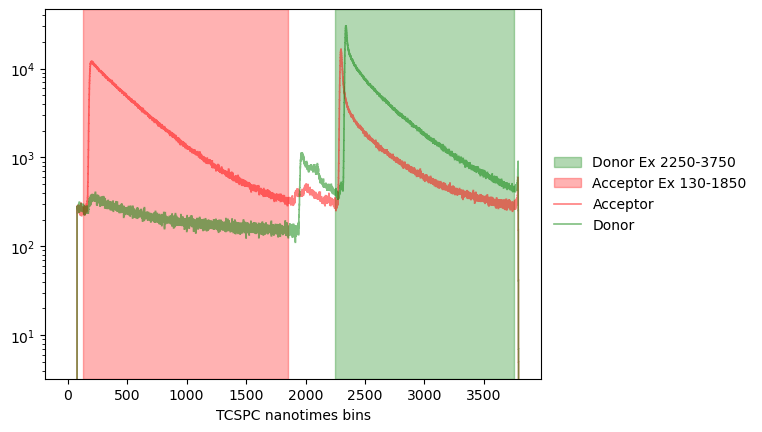

In [3]:
frb.rawplot.alternation_hist(raw)

Once you have ensured that all values are set and are correct, 
(if files converted to HDF5 correctly, you shouldn't have to set anything)
use the `frb.photonHDF5.normalize()` function to create a `PhotonData` object.

In [4]:
data = frb.photonHDF5.normalize(raw)

`PhotonData` objects are the main organizer of data in FRETBurts.

As we will see, FRETBursts has 2 main types of objects:
1. Data
2. Instruction

Data objects store the actual data, and `PhotonData` is the main type of data object.
Instruction objects give instructions for how to process and compute values within data objects.

Next, we will see how to crate these instructions, and give them to the `PhotonData` object to retrieve the values we are interested in.

## Defining Background

To start with, the background must be defined. 
We can create a `frb.Param` object (`frb.Param` is an "instruction" type of object) defining the background with the `frb.bg.make_bg_param()` function.

The kwargs are:
- `period` specifies the duration (in seconds) for a given background period. and func specifies what function to use in assessing the background.
- `tail_min` minimum interphoton time to include in background estimation.
- `func` function (either `frb.bg.exp_mlefit()`, `frb.bg.exp_cdffit()` or `frb.exp_histfit()`) to use to fit the background

In [5]:
prbg60 = frb.make_bg_param(data, period=60.0, tail_min=5e-4, func=frb.bg.exp_mlefit)

The sort of computation a `frb.Param` object defines is defined by the `frb.Param.tp` attribute.
This is always a class, it defines the "type" of the `frb.Param`.

The `frb.make_bg_param()` returns a `frb.Param` of type `frb.BG`

In [6]:
prbg60.tp

fretbursts.background.BG

The `prbg60` object is *not* the actual computation, it generates a `frb.Param` object which are the *instructions* for how to compute the bg.

To compute and examine the background, we need to give the `prbg60` object to `data`.
This can be done in several ways, often "behind the scenes".

We can get the base "table" out of a `data` using the `frb.PhotonData.get_table` method:

In [7]:
prbg60tb = data.get_table(prbg60)

You will rarely use this method, using it here will be useful to introduce how `frb.Column` objects work.

`frb.datamodel.tables.Table` objects, as there name implies represent tables of values, with rows and columns.
Not all rows/columns are computed immediately, they instead must be "requested".

A given column is "requested" by indexing into it.
The columns available are dependant on the `frb.Param` used to request it.

For those of the type returned by `frb.bg.make_bg_param`, the primary row is
`['bg', <<ph_sel>>]` see below:

In [8]:
prbg60tb['bg', frb.PhSel('0ex0em')]

array([707.05512322, 747.14575305, 738.33848324, 736.98424204,
       734.629228  , 743.05753454, 715.47183589, 712.47625089,
       702.00862731, 684.36509401, 672.38114603, 670.36328658,
       681.93236193, 698.68456485, 721.65295359, 705.30466453,
       729.65898127, 700.88471542, 681.52612893, 677.4692246 ,
       671.075476  , 647.36997022, 642.42530226, 662.71879676,
       650.28833793, 648.34505285, 643.98720491, 644.66037837,
       661.73300348, 672.12394797, 694.88022763, 691.2931011 ,
       690.83903081, 701.72328479, 725.42599359, 721.97424206,
       745.07427721, 744.67658482, 766.52380066, 757.97967054,
       748.09241292, 713.59280436, 702.47405344, 691.86893719,
       691.73256911, 683.07724636, 700.96091885, 716.91140883,
       733.95590074, 726.8356299 , 705.64814219, 697.20788701,
       676.1841615 , 680.41655984, 665.45549959, 667.43652987,
       675.69067027, 682.78992101, 678.47525534, 669.6019951 ,
       667.87626426, 667.88612042, 656.15264169, 683.50

This is the background count rate for each time period. You are seeing a "column" of the table.

FRETBursts identifies photon streams with `frb.PhSel` objects, which we will delve into deeper later.
But for now, understand that `frb.PhSel('0ex0em')` takes the string (`'0ex0em'`) and parses it into a stream definition.

This means the 0th excitation (ex), and 0th emmission channels(em) (ie Donor-Donor).

`frb.PhSel('0ex')` would specify all emmissions, but only from the 0th excitation (Donor-excitaiton-Donor-emission+Donor-excitation-Acceptor-emission).

Now we can introduce `frb.Column` objects.
These are ways to specify a column in a `Table` and hand it around to all sorts of plotting and other functions.

To create a column object, you need 3 things:
1. `frb.Param` object
2. the column name
3. column keys

The column name is always the first thing specified in indexing into a `Table` object, so for the above example, it is `'bg'`.
The column keys are whatever comes afterwards, these are any additional definitions that should be included.
For `'bg'` columns, this is a `frb.Ph_sel`, because we need to know which photon stream we are looking at.

Below we create a column for the same column we accesed from the table before:

In [9]:
cbgDD60 = frb.Column(prbg60, 'bg', frb.PhSel('0ex0em'))

We can look at it's values with another `frb.PhotonData.get_...()` method: `frb.PhotonData.get_column()`.
This one you will likely use more often.

In [10]:
data.get_column(cbgDD60)

array([707.05512322, 747.14575305, 738.33848324, 736.98424204,
       734.629228  , 743.05753454, 715.47183589, 712.47625089,
       702.00862731, 684.36509401, 672.38114603, 670.36328658,
       681.93236193, 698.68456485, 721.65295359, 705.30466453,
       729.65898127, 700.88471542, 681.52612893, 677.4692246 ,
       671.075476  , 647.36997022, 642.42530226, 662.71879676,
       650.28833793, 648.34505285, 643.98720491, 644.66037837,
       661.73300348, 672.12394797, 694.88022763, 691.2931011 ,
       690.83903081, 701.72328479, 725.42599359, 721.97424206,
       745.07427721, 744.67658482, 766.52380066, 757.97967054,
       748.09241292, 713.59280436, 702.47405344, 691.86893719,
       691.73256911, 683.07724636, 700.96091885, 716.91140883,
       733.95590074, 726.8356299 , 705.64814219, 697.20788701,
       676.1841615 , 680.41655984, 665.45549959, 667.43652987,
       675.69067027, 682.78992101, 678.47525534, 669.6019951 ,
       667.87626426, 667.88612042, 656.15264169, 683.50

Note that `data.get_column(cbgDD60)` returned the same values as `prbg60tb['bg', frb.Ph_sel('0ex0em')]`, because indeed, these two are equivalent.

Now, getting a raw array is often annoying.
For real data analysis, we will typically want to plot this.

Thankfully, FRETBursts provides a number of convenience functions for plotting columns.

Below we have the `frb.plot.time_plot` and `frb.plot.time_scatter` functions, which take a `frb.PhotonData` and `frb.Column` object as input,
and plot the value on the y-axis and the time of the event.
These do have some additional keyword arguments, not important for now, and pass any other keyword arguments to either
[plt.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot) 
or 
[plt.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html#matplotlib.axes.Axes.scatter) 
depening on which function called.

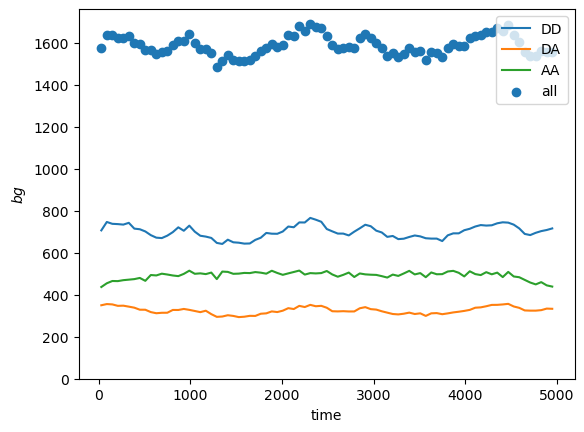

In [11]:
bgDD = frb.Column(prbg60, 'bg', frb.PhSel('0ex0em'))
bgDA = frb.Column(prbg60, 'bg', frb.PhSel('0ex1em'))
bgAA = frb.Column(prbg60, 'bg', frb.PhSel('1ex1em'))
bgAll = frb.Column(prbg60, 'bg', frb.PhSel('all'))

frb.plot.time_plot(data, bgDD, label='DD')
frb.plot.time_plot(data, bgDA, label='DA')
frb.plot.time_plot(data, bgAA, label='AA')
frb.plot.time_scatter(data, bgAll, label='all')
plt.ylim(0)
plt.legend()

## Burst Search

Now we can define how to conduct the burst search.

The function `frb.make_burst_search()` creates a `frb.Param` defining a burst search.
The output `frb.Param` object will have a type of `frb.Bursts`

In [12]:
bursts = frb.make_burst_search(prbg60, 10, 6.0)

The full signature of `frb.make_burst_search()` is :

`frb.make_burst_search(bg:frb.Param, m:int, F:float, stream:frb.PhSel=frb.PhSel('0ex_1em'))->frb.Param`

The `frb.Param` object returned is a base burst search, which defines the bursts.
Bursts are fundamentally defined by start and stop times.
The rest of the parameters are in some way defined by the photons in the raw data between the start and stop times.

The `bursts` param has many columns.
We will introduce them bit by bit.

The first column that will be of interest is "nph", like the "bg" column before, this column needs a `frb.PhSel` key to select which stream of photons it specifies.
This is the **raw** number of photons in the given stream.
It is **not** corrected for background or for cross-talk like leakage and direct excitation or differing detection efficies and laser powers ($\gamma$ and $beta$ factors).
(We will see how we can get those corrections from other columns later).

To visualize the different sizes of bursts, lets introduce another plotting function:
`frb.plot.scatter` is a wrapper of matplotlib's [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html#matplotlib.axes.Axes.scatter) function. Just give it the data, and 2 columsn to plot on the x and y axes respectively:

(-5.0, 200.0)

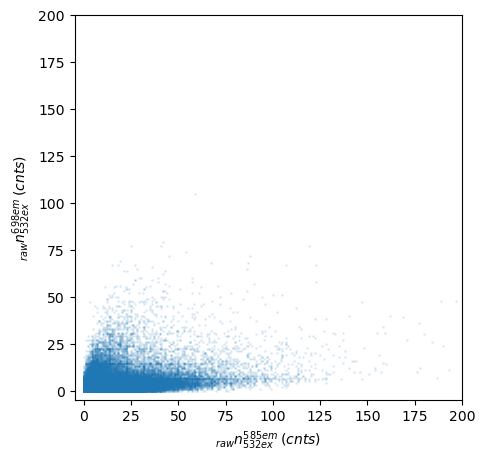

In [13]:
nphD_raw = frb.Column(bursts, 'nph_raw', frb.PhSel('0ex'))
nphDD_raw = frb.Column(bursts, 'nph_raw', frb.PhSel('0ex0em'))
nphDA_raw = frb.Column(bursts, 'nph_raw', frb.PhSel('0ex1em'))
nphAA_raw = frb.Column(bursts, 'nph_raw', frb.PhSel('1ex1em'))

fig, ax = plt.subplots(figsize=(5,5))
frb.plot.scatter(data, nphDD_raw, nphDA_raw, s=1.0, alpha=0.1, include_unit=True, ax=ax)
ax.set_xlim([-5, 200])
ax.set_ylim([-5, 200])

### Gates

You will also notice that the minimum number of photons is quite low.
This is because the bursts have not been gated for total number of photons.
The burst-search uses a sliding window, which means that only a minimum of $m$ photons need been bunched together close enough to count as a burst.

Therefore it is customary to set a threshold for the minimum number of photons for which a burst must have in order for us to consider it.

This is done using `GateGroup` objects.
To only consider bursts with more than a certain value in a certain column, we use the `frb.make_gte_gate()` function (gte is short for greater than or equal to).

Simply define a column and threshold, and it creates the gate for you.

In [14]:
nphAll_raw = frb.Column(bursts, 'nph_raw', frb.PhSel('0ex_1ex1em'))
gateAll = frb.make_gte_gate(nphAll_raw, 50)

Now we can see the effect of applying the gate:

(-5.0, 200.0)

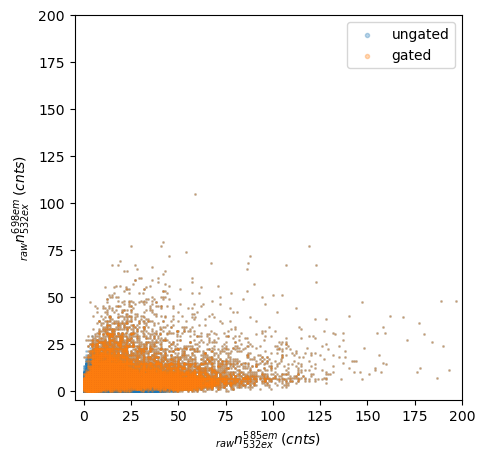

In [15]:
fig, ax = plt.subplots(figsize=(5,5))
frb.plot.scatter(data, nphDD_raw, nphDA_raw, s=1.0, alpha=0.3, include_unit=True, label='ungated', ax=ax)
frb.plot.scatter(data, nphDD_raw, nphDA_raw, gate=gateAll, s=1.0, alpha=0.3, include_unit=True, label='gated', ax=ax)
plt.legend(markerscale=3)
ax.set_xlim([-5, 200])
ax.set_ylim([-5, 200])

We can also add this gate to the instruction objects with the `frb.Column.regate()` method.
This *returns* a new object, with the gate applied.
It does not change the original object.

(-5.0, 200.0)

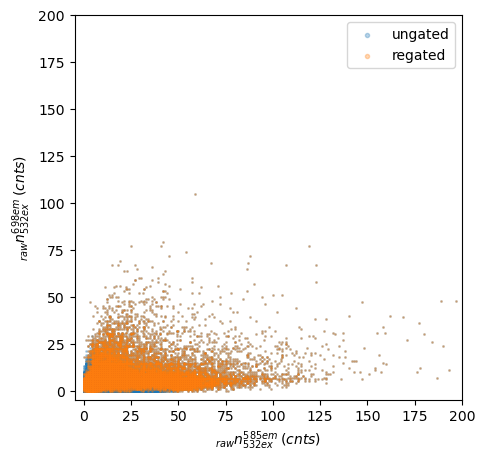

In [16]:
nphDD_raw_g = nphDD_raw.regate(gateAll)
nphDA_raw_g = nphDA_raw.regate(gateAll)

fig, ax = plt.subplots(figsize=(5,5))
frb.plot.scatter(data, nphDD_raw, nphDA_raw, s=1.0, alpha=0.3, include_unit=True, label='ungated', ax=ax)
frb.plot.scatter(data, nphDD_raw_g, nphDA_raw_g, s=1.0, alpha=0.3, include_unit=True, label='regated', ax=ax)
plt.legend(markerscale=3)
ax.set_xlim([-5, 200])
ax.set_ylim([-5, 200])

`frb.Param` objects also have a `frb.Param.regate()` method.
`frb.Column`s created from such `frb.Param`s inherit the gate:

(-5.0, 200.0)

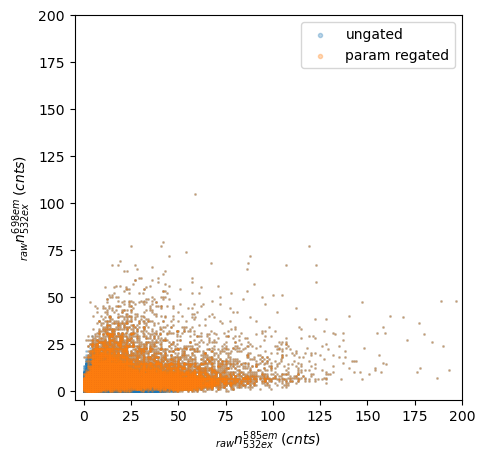

In [17]:
bursts_g = bursts.regate(gateAll)

nphDD_raw_pg = frb.Column(bursts_g, 'nph_raw', frb.PhSel('0ex0em'))
nphDA_raw_pg = frb.Column(bursts_g, 'nph_raw', frb.PhSel('0ex1em'))

fig, ax = plt.subplots(figsize=(5,5))
frb.plot.scatter(data, nphDD_raw, nphDA_raw, s=1.0, alpha=0.3, include_unit=True, label='ungated', ax=ax)
frb.plot.scatter(data, nphDD_raw_pg, nphDA_raw_pg, s=1.0, alpha=0.3, include_unit=True, label='param regated', ax=ax)
plt.legend(markerscale=3)
ax.set_xlim([-5, 200])
ax.set_ylim([-5, 200])

### E and S 

Now we reach the point that most people look at with smFRET data: fret efficiency (E) and stoichiometry (S).

Columns for these parametes come from `frb.Param` objects of type `frb.Ratios`.
This type computes ratios of *bg and cross-talk corrected* streams.
Since E and S are fundamentally ratios, this is where we get these parameters.

To create such a `frb.Param` we use the `frb.make_correction_factors()` function.
It's full signature is: `frb.make_correction_factors(bursts:frb.Param, gamma:float=1.0, beta:float=1.0, lk:float=0.0, dir_ex:float=0.0)->tuple[frb.Param, frb.Param]`

Note that it returns a 2-tuple of `frb.Param` objects.
The first is a `frb.Param` of type `frb.NphBG`, which is for bg but not cross-talk corrected values.
The second is a `frb.Param` of type `frb.Ratios` which provides the fully corrected values.

> **Note**
>
> With the default parameters, there is no cross-talk.
> Thus results of photon counts will be the same between the `frb.NphBG` and `frb.Ratios` params.

In [18]:
nph, ratio = frb.make_correction_factors(bursts)
nph_g, ratio_g = frb.make_correction_factors(bursts_g) # note that gate of bursts_g is kept

In [19]:
gateDAA = frb.make_gte_gate(nphD_raw, 50) & frb.make_gte_gate(nphAA_raw, 25)

(-0.1, 1.1)

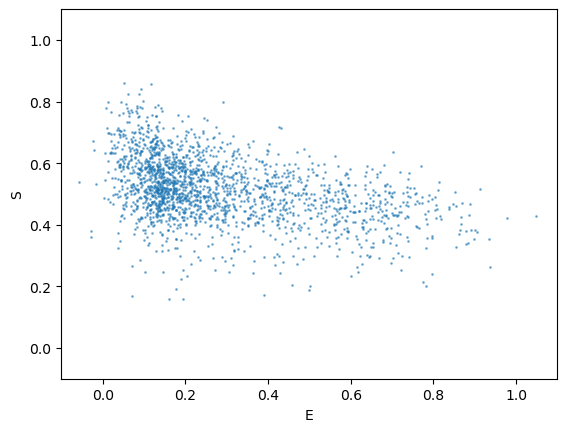

In [20]:
E = frb.Column(ratio_g, 'E')
S = frb.Column(ratio_g, 'S')

frb.plot.scatter(data, E, S, gate=gateDAA, s=1.0, alpha=0.5, )#density_func=frb.plot.density_kde)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

In [21]:
tDD = np.argmax(data.get_column(frb.Column(bursts, 'nanohist', (frb.PhSel('0ex0em'), True))).sum(axis=0))
tDA = np.argmax(data.get_column(frb.Column(bursts, 'nanohist', (frb.PhSel('0ex1em'), True))).sum(axis=0))
tAA = np.argmax(data.get_column(frb.Column(bursts, 'nanohist', (frb.PhSel('1ex1em'), True))).sum(axis=0))

In [22]:
tDD, tDA, tAA

(2342, 2298, 209)

In [23]:
data.irf_thresh[frb.PhSel('0ex0em')] = tDD
data.irf_thresh[frb.PhSel('0ex1em')] = tDA
data.irf_thresh[frb.PhSel('1ex1em')] = tAA

(<matplotlib.collections.PathCollection at 0x788343125ff0>,
 Text(0.5, 0, 'E'),
 Text(0, 0.5, 'S'))

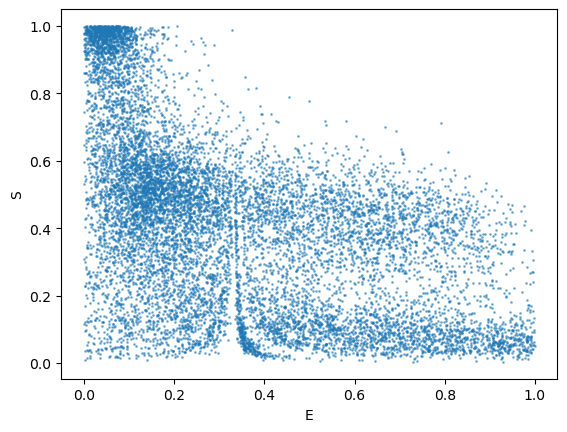

In [24]:
# E = frb.Column(ratio_g, 'E')
# S = frb.Column(ratio_g, 'S')

gateBox = gateAll & frb.make_gte_gate(E, 0.0) & frb.make_lt_gate(E, 1.0) & frb.make_gte_gate(S, 0.0) & frb.make_lt_gate(S, 1.0)

frb.plot.scatter(data, E, S, gate=gateBox, s=1.0, alpha=0.5, )#density_func=frb.plot.density_kde)
# plt.xlim([-0.1, 1.1])
# plt.ylim([-0.1, 1.1])

(-0.1, 1.1)

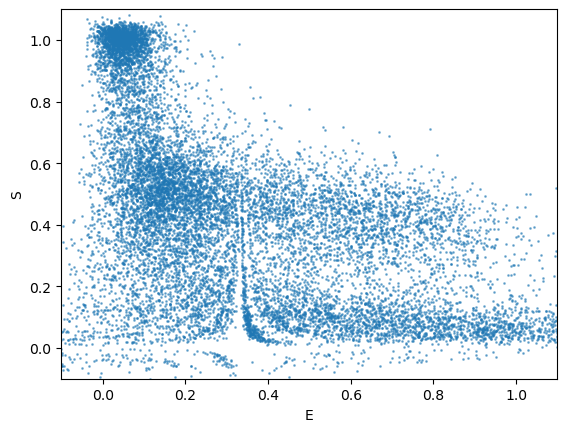

In [25]:
E = frb.Column(ratio_g, 'E')
S = frb.Column(ratio_g, 'S')

frb.plot.scatter(data, E, S, s=1.0, alpha=0.5)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

Param     | name       | notes
----------|------------|---------------------------------------------------------------------------------------------------------------------------------------
 `bursts` | `"nph"`    | integer always non-negative, number of photons in stream with no adjustments for background etc.
 `nph`    | `"nph_bg"` | background adjusted number of photons, floating point, no correction for cross-talk or detector sensitivity
 `ratio`  | `"nph_c"   | fully corrected stream counts, floating point, takes into account all correction factors, the "effective" intensity of a given channel


In [26]:
nphAll = frb.Column(bursts, 'nph_raw', frb.PhSel('0ex_1ex1em'))
gateAll = frb.make_gte_gate(nphAll, 50)

$$ PR = \frac{n_{DexAem}}{n_{DexDem}+n_{DexAem}} $$

$$
\begin{bmatrix} 
f_{DexDem,DexDem} & f_{DexDem,DexAem} & f_{DexDem,AexDem} & f_{DexDem,AexAem} \\
f_{DexAem,DexDem} & f_{DexAem,DexAem} & f_{DexAem,AexDem} & f_{DexAem,AexAem} \\
f_{AexDem,DexDem} & f_{AexDem,DexAem} & f_{AexDem,AexDem} & f_{AexDem,AexAem} \\
f_{AexAem,DexDem} & f_{AexAem,DexAem} & f_{AexAem,AexDem} & f_{AexAem,AexAem}
\end{bmatrix}
\begin{bmatrix} n_{DexDem} \\ n_{DexAem} \\ n_{AexDem} \\ n_{DexDem} \end{bmatrix} =
\begin{bmatrix} s_{DexDem} \\ s_{DexAem} \\ s_{AexDem} \\ s_{DexDem} \end{bmatrix}
$$

$$ E = \frac{s_{DexAem}}{s_{DexDem}+s_{DexAem}} $$

<Axes: xlabel='E'>

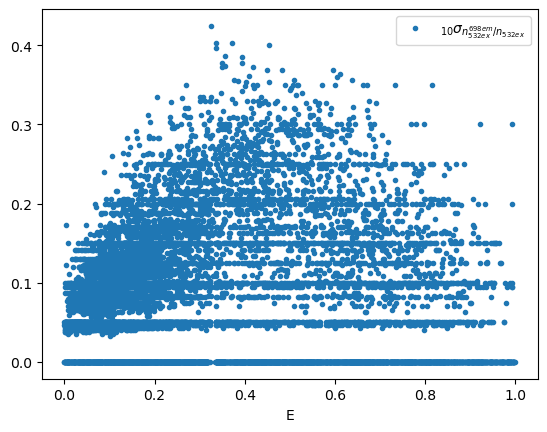

In [27]:
data.get_frame(frb.Column(ratio.regate(gateBox), 'E'), frb.Column(bursts.regate(gateBox), 'bva', (frb.PhSel('0ex1em'), frb.PhSel('0ex'), 10))).plot(x='E', marker='.', lw=0)

In [28]:
data.get_table(bursts).record_column('bva', frb.PhSel('0ex1em'), frb.PhSel('0ex'), 10)

array([0.08164966, 0.12247449, 0.        , ..., 0.        , 0.04714045,
       0.        ])

In [29]:
gF = frb.make_gte_gate(frb.Column(bursts, 'nph_raw', frb.PhSel('0ex')), 50)
gFB = gF & gateBox
ratio_gfb = ratio.regate(gFB)
bursts_gfb = bursts.regate(gFB)
E_gfb = frb.Column(ratio_gfb, 'E')
bva_gfb = frb.Column(bursts_gfb, 'bva', (frb.PhSel('0ex1em'), frb.PhSel('0ex'), 10))

(<matplotlib.collections.PathCollection at 0x788342a18a00>,
 Text(0.5, 0, 'E'),
 Text(0, 0.5, '$_{10}\\sigma_{n_{532ex}^{698em}/n_{532ex}}$'))

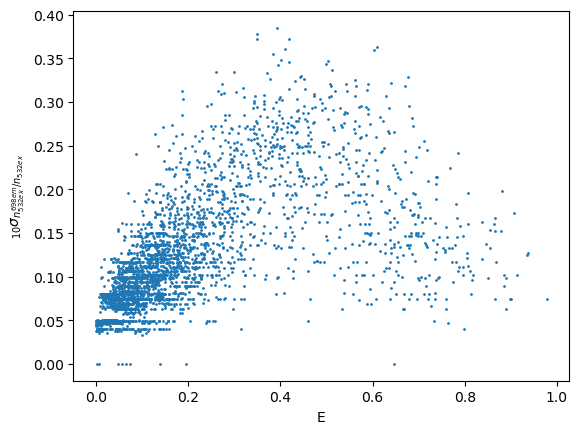

In [30]:
frb.plot.scatter(data, E_gfb, bva_gfb, s=1.0)